# CogniFlow - Stage 2b: DAiSEE Validation
234 clips: 117 extreme high-risk (Boredom=3, Engagement≤1) vs
117 extreme engaged (Engagement=3, Boredom=0, Frustration=0).

In [1]:
!pip install -q ultralytics opencv-python pandas numpy matplotlib seaborn scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.0 MB/s eta 0:00:00


In [2]:
import cv2, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
from ultralytics import YOLO
np.random.seed(42)
print('Imports OK')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Imports OK


## Step 1 - Load Model

In [3]:
MODEL_PATH = '/kaggle/input/datasets/tejasgovind/yolov8-pose/yolov8n-pose.pt'
model = YOLO(MODEL_PATH) if os.path.exists(MODEL_PATH) else YOLO('yolov8n-pose.pt')
print('Model ready.')

Model ready.


## Step 2 - Define Labels (117 high-risk + 117 engaged)

In [4]:
high_risk_clips = ['1100021055.avi', '1100042023.avi', '1100052014.avi', '1100162016.avi', '1100171008.avi', '1100412018.avi', '1100412033.avi', '1100412039.avi', '1110031025.avi', '1110031038.avi', '1813740184.avi', '2000501030.avi', '2100532022.avi', '2100551005.avi', '2100551010.avi', '2100551042.avi', '2100571007.avi', '2100571049.avi', '2100582052.avi', '2100582055.avi', '2100582056.avi', '2100582057.avi', '2100582058.avi', '2100582060.avi', '2100582061.avi', '2100582062.avi', '2100611027.avi', '2260510163.avi', '303830139.mp4', '3100662037.avi', '3100681017.avi', '3100751007.avi', '3100751056.avi', '3100752014.avi', '3100761008.avi', '3100821075.avi', '3100822011.avi', '3100822031.avi', '3100822066.avi', '3344630131.avi', '4000181004.avi', '4000301005.avi', '4000301028.avi', '4000301049.avi', '4000301066.avi', '4000301067.avi', '4000301070.avi', '4000332082.avi', '4100191033.avi', '4100192026.avi', '4100192029.avi', '4100192031.avi', '4100192049.avi', '4100192053.avi', '4100201030.avi', '4100201032.avi', '4100242032.avi', '4100242033.avi', '4100242035.avi', '4100251027.avi', '4100251028.avi', '4100251029.avi', '4100251033.avi', '4100251036.avi', '4100251038.avi', '4100251057.avi', '4100251061.avi', '4100251068.avi', '4100252036.avi', '4100252041.avi', '4100252044.avi', '4100262004.avi', '4100281067.avi', '4100291006.avi', '4100291007.avi', '4100291027.avi', '4100291084.avi', '4100302013.avi', '4100302016.avi', '4100302018.avi', '4100302040.avi', '4100302042.avi', '4100302044.avi', '4100302045.avi', '4100302048.avi', '4100302055.avi', '4100302058.avi', '4100302064.avi', '4100321042.avi', '4110211013.avi', '4110211014.avi', '4110211023.avi', '4110211025.avi', '4110211027.avi', '4110211028.avi', '4110211039.avi', '4110211045.avi', '4110212034.avi', '4110212049.avi', '4110212062.avi', '4110311045.avi', '5000391056.avi', '5000951023.avi', '5000952083.avi', '5100342022.avi', '5100342024.avi', '5100342028.avi', '5100342036.avi', '5564630211.avi', '79940202490.mp4', '79940202800.mp4', '8264120169.avi', '8264120243.avi', '8264120249.avi', '8264120256.avi', '8264120261.avi', '9289010152.avi']

engaged_clips = ['5912920156.avi', '3503610122.avi', '3100621041.avi', '2100511072.avi', '2100592069.avi', '3503610233.avi', '2100561020.avi', '1100011047.avi', '1100171064.avi', '3100822051.avi', '4000301072.avi', '4000331008.avi', '4140810128.avi', '5100461053.avi', '181374029.avi', '33702101630.mp4', '33702102280.mp4', '7698620240.avi', '5221290238.avi', '3503610270.avi', '5100401014.avi', '8263820170.mp4', '79940202120.mp4', '5100351039.avi', '3100781069.avi', '2100531080.avi', '5000672006.avi', '1100062007.avi', '3422270128.avi', '4140810143.avi', '5564630230.avi', '248510211.mp4', '1100012001.avi', '33702102540.mp4', '3100722013.avi', '3100631032.avi', '2100581056.avi', '2100611066.avi', '3422270123.avi', '591292021.avi', '2100531028.avi', '3100621026.avi', '5912920274.avi', '9403280155.avi', '3100721054.avi', '4000301052.avi', '4000301025.avi', '1100411013.avi', '88265401270.mp4', '4000231070.avi', '3503610125.avi', '5100452028.avi', '414081025.avi', '3100782068.avi', '1100022056.avi', '29042802690.mp4', '2100562002.avi', '1100022028.avi', '5100092013.avi', '3100761063.avi', '5000442065.avi', '9403280262.avi', '2100591048.avi', '5000441071.avi', '5100352031.avi', '2000501076.avi', '2000541074.avi', '1100112051.avi', '5221290144.avi', '2100511060.avi', '8263820151.mp4', '3100782032.avi', '4018350220.mp4', '2000482039.avi', '2100551049.avi', '5000952025.avi', '414081026.avi', '5912920147.avi', '29042802430.mp4', '2408460265.avi', '4599990131.avi', '3100642013.avi', '5100462075.avi', '3100741019.avi', '5912920213.avi', '2100561021.avi', '4599990134.avi', '4100272043.avi', '5100461017.avi', '1100051071.avi', '1100121045.avi', '2000501033.avi', '1100121010.avi', '3100731026.avi', '5100092008.avi', '5564630153.avi', '2100532054.avi', '5000952070.avi', '5100381024.avi', '2100521002.avi', '4100292046.avi', '4140810185.avi', '1100011069.avi', '3100722059.avi', '2100511082.avi', '522129025.avi', '4140810239.avi', '2100551050.avi', '3503610273.avi', '3422270238.avi', '2100531076.avi', '5221290122.avi', '2408460257.avi', '769862022.avi', '2100512052.avi', '3503610261.avi', '248510229.mp4']

labels_df = pd.DataFrame(
    [{'ClipID': c, 'label': 'high_risk'} for c in high_risk_clips] +
    [{'ClipID': c, 'label': 'engaged'} for c in engaged_clips]
)
print(f'Labels ready: {len(labels_df)} clips')
print(labels_df['label'].value_counts())

Labels ready: 234 clips
label
high_risk    117
engaged      117
Name: count, dtype: int64


## Step 3 - Feature Extraction Functions

In [5]:
def distance(p1, p2):
    return np.linalg.norm(np.array(p1) - np.array(p2))

def compute_gaze_score(kp):
    nose, le, re = kp[0], kp[1], kp[2]
    eye_center = (le + re) / 2
    eye_width = distance(le, re)
    if eye_width < 1e-3: return 0.5
    return float(max(0, min(1, 1 - abs(nose[0] - eye_center[0]) / eye_width)))

def compute_head_pose_score(kp):
    nose, la, ra = kp[0], kp[3], kp[4]
    ear_center = (la + ra) / 2
    ear_width = distance(la, ra)
    if ear_width < 1e-3: return 0.5
    return float(max(0, min(1, 1 - abs(nose[0] - ear_center[0]) / ear_width)))

def compute_posture_score(kp):
    ls, rs = kp[5], kp[6]
    sw = distance(ls, rs)
    if sw < 1e-3: return 0.5
    return float(max(0, min(1, 1 - abs(ls[1] - rs[1]) / sw)))

def compute_eye_openness(kp):
    nose, le, re = kp[0], kp[1], kp[2]
    eye_y = (le[1] + re[1]) / 2
    return float(max(0.005, min(0.05, abs(nose[1] - eye_y) / 1000.0)))

print('Feature functions ready.')

Feature functions ready.


## Step 4 - Process All 234 Clips

In [ ]:
import os
CLIP_DIR = None
for root, dirs, files in os.walk('/kaggle/input/'):
    for f in files:
        if f.endswith('.avi') or f.endswith('.mp4'):
            CLIP_DIR = root
            break
    if CLIP_DIR: break

print(f'Clip directory: {CLIP_DIR}')

all_videos = {}
for f in os.listdir(CLIP_DIR):
    if f.endswith('.avi') or f.endswith('.mp4'):
        all_videos[f] = os.path.join(CLIP_DIR, f)
print(f'Found {len(all_videos)} video files')

Clip directory: /kaggle/input/datasets/tejasgovind/daisee-subsetv3/daisee_subset_v3
Found 234 video files


In [7]:
results = []
failed = []
start_time = time.time()

for idx, row in labels_df.iterrows():
    clip_id = row['ClipID']
    label   = row['label']

    if clip_id not in all_videos:
        failed.append(clip_id)
        continue

    cap = cv2.VideoCapture(all_videos[clip_id])
    if not cap.isOpened():
        failed.append(clip_id)
        continue

    gaze_scores, head_scores, posture_scores, eye_scores = [], [], [], []
    frame_count = 0

    while True:
        ret, frame = cap.read()
        if not ret: break
        frame_count += 1
        if frame_count % 3 != 0: continue

        res = model(frame, verbose=False)
        if res[0].keypoints is None: continue
        kp_data = res[0].keypoints.xy.cpu().numpy()
        if len(kp_data) == 0: continue
        kp = kp_data[0]
        if kp.shape[0] < 7: continue

        gaze_scores.append(compute_gaze_score(kp))
        head_scores.append(compute_head_pose_score(kp))
        posture_scores.append(compute_posture_score(kp))
        eye_scores.append(compute_eye_openness(kp))

    cap.release()

    if len(gaze_scores) < 3:
        failed.append(clip_id)
        continue

    results.append({
        'clip_id':          clip_id,
        'label':            label,
        'avg_gaze':         np.mean(gaze_scores),
        'gaze_variance':    np.var(gaze_scores),
        'avg_head_pose':    np.mean(head_scores),
        'avg_eye_openness': np.mean(eye_scores),
        'avg_posture':      np.mean(posture_scores),
        'frames_processed': len(gaze_scores)
    })

    if (idx + 1) % 20 == 0:
        elapsed = time.time() - start_time
        print(f'[{len(results)}/{len(labels_df)}] processed | failed={len(failed)} | elapsed={elapsed/60:.1f}m')

df_daisee = pd.DataFrame(results)
print(f'\nDone: {len(df_daisee)} clips processed, {len(failed)} failed')
print(df_daisee['label'].value_counts())

[20/234] processed | failed=0 | elapsed=0.4m
[40/234] processed | failed=0 | elapsed=0.7m
[60/234] processed | failed=0 | elapsed=1.0m
[80/234] processed | failed=0 | elapsed=1.4m
[100/234] processed | failed=0 | elapsed=1.7m
[120/234] processed | failed=0 | elapsed=2.0m
[140/234] processed | failed=0 | elapsed=2.4m
[160/234] processed | failed=0 | elapsed=2.7m
[180/234] processed | failed=0 | elapsed=3.1m
[200/234] processed | failed=0 | elapsed=3.4m
[220/234] processed | failed=0 | elapsed=3.7m

Done: 234 clips processed, 0 failed
label
high_risk    117
engaged      117
Name: count, dtype: int64


## Step 5 - Statistical Validation

In [8]:
features = ['avg_gaze', 'gaze_variance', 'avg_head_pose', 'avg_eye_openness']

high_risk = df_daisee[df_daisee['label'] == 'high_risk']
engaged   = df_daisee[df_daisee['label'] == 'engaged']

print('=== Mann-Whitney U Test: high_risk vs engaged ===')
print(f"{'Feature':<22} {'Risk Mean':>10} {'Engaged Mean':>13} {'p-value':>10} {'Significant':>12}")
print('-' * 72)

stat_results = []
for feat in features:
    r = high_risk[feat].dropna()
    e = engaged[feat].dropna()
    u_stat, p_val = stats.mannwhitneyu(r, e, alternative='two-sided')
    sig = 'Yes *' if p_val < 0.05 else 'No'
    print(f'{feat:<22} {r.mean():>10.4f} {e.mean():>13.4f} {p_val:>10.4f} {sig:>12}')
    stat_results.append({
        'feature': feat,
        'risk_mean': r.mean(),
        'engaged_mean': e.mean(),
        'p_value': p_val,
        'significant': p_val < 0.05
    })

stats_df = pd.DataFrame(stat_results)
print(f"\n{stats_df['significant'].sum()}/{len(features)} features show significant separation (p<0.05)")

=== Mann-Whitney U Test: high_risk vs engaged ===
Feature                 Risk Mean  Engaged Mean    p-value  Significant
------------------------------------------------------------------------
avg_gaze                   0.9353        0.9522     0.1852           No
gaze_variance              0.0040        0.0027     0.0044        Yes *
avg_head_pose              0.9393        0.9521     0.2252           No
avg_eye_openness           0.0312        0.0316     0.7831           No

1/4 features show significant separation (p<0.05)


## Step 6 - Visualizations for Final Report

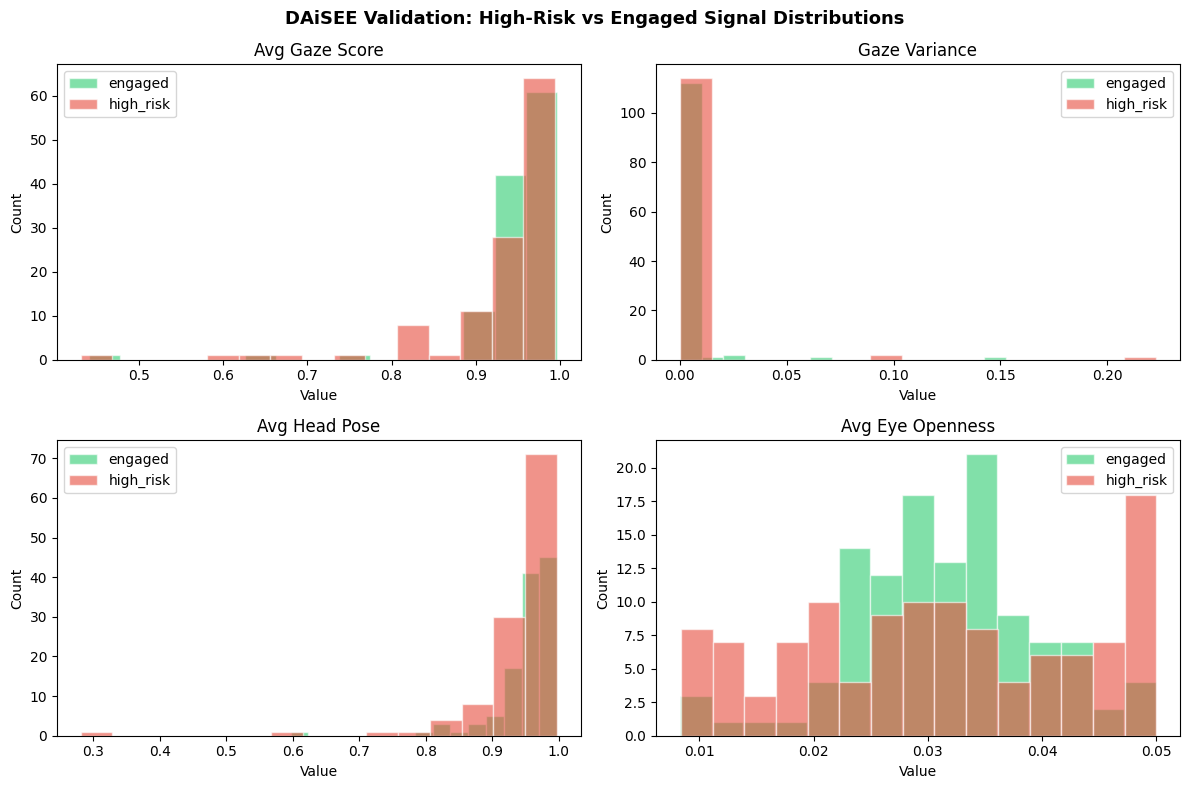

Saved daisee_validation_distributions.png


In [9]:
colors = {'high_risk': '#e74c3c', 'engaged': '#2ecc71'}
titles = ['Avg Gaze Score', 'Gaze Variance', 'Avg Head Pose', 'Avg Eye Openness']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('DAiSEE Validation: High-Risk vs Engaged Signal Distributions', fontsize=13, fontweight='bold')

for ax, feat, title in zip(axes.flat, features, titles):
    for lbl, grp in df_daisee.groupby('label'):
        ax.hist(grp[feat], bins=15, alpha=0.6, label=lbl, color=colors[lbl], edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.savefig('/kaggle/working/daisee_validation_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved daisee_validation_distributions.png')

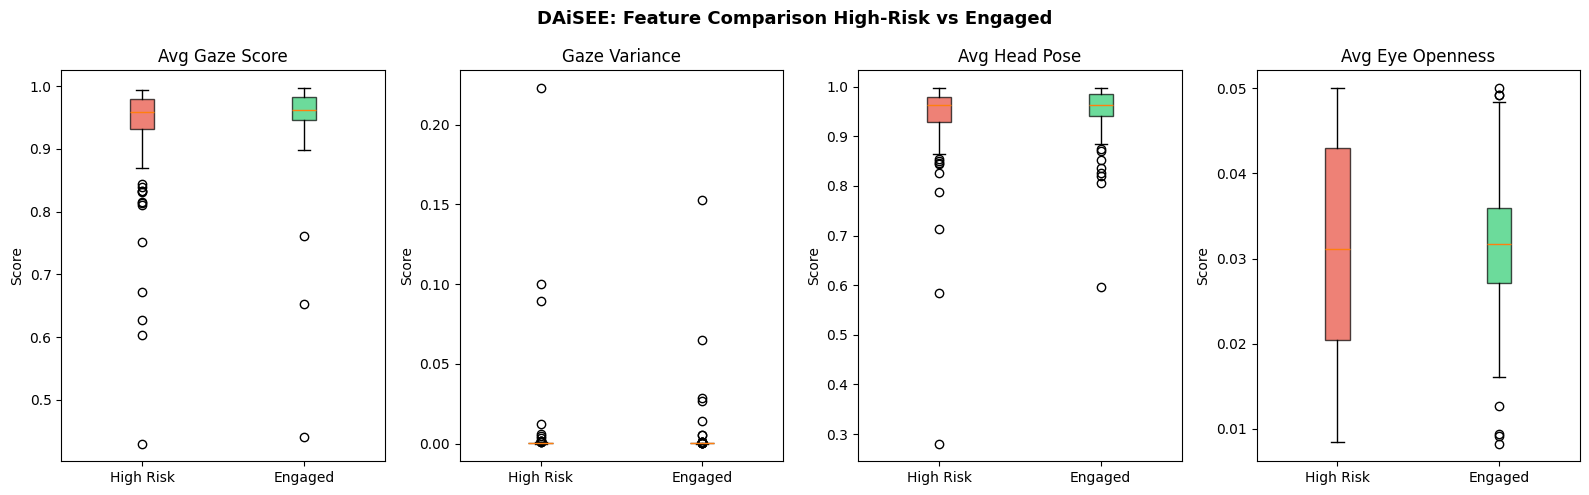

Saved daisee_validation_boxplots.png


In [10]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('DAiSEE: Feature Comparison High-Risk vs Engaged', fontsize=13, fontweight='bold')

for ax, feat, title in zip(axes, features, titles):
    data = [high_risk[feat].dropna().values, engaged[feat].dropna().values]
    bp = ax.boxplot(data, patch_artist=True, labels=['High Risk', 'Engaged'])
    bp['boxes'][0].set_facecolor('#e74c3c')
    bp['boxes'][1].set_facecolor('#2ecc71')
    for box in bp['boxes']: box.set_alpha(0.7)
    ax.set_title(title)
    ax.set_ylabel('Score')

plt.tight_layout()
plt.savefig('/kaggle/working/daisee_validation_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved daisee_validation_boxplots.png')

## Step 7 - Save Results

In [11]:
df_daisee.to_csv('/kaggle/working/daisee_features.csv', index=False)
stats_df.to_csv('/kaggle/working/daisee_stats.csv', index=False)

print('Saved daisee_features.csv')
print('Saved daisee_stats.csv')

print('\n=== Summary for Final Report ===')
print(df_daisee.groupby('label')[features].mean().round(4))

Saved daisee_features.csv
Saved daisee_stats.csv

=== Summary for Final Report ===
           avg_gaze  gaze_variance  avg_head_pose  avg_eye_openness
label                                                              
engaged      0.9522         0.0027         0.9521            0.0316
high_risk    0.9353         0.0040         0.9393            0.0312
